In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Load data ─────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'XGBoost version : {xgb.__version__}')
print(f'Dataset shape   : {df.shape}')
df.head(3)

XGBoost version : 3.2.0
Dataset shape   : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


1. **Preprocessing**

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(mapping)

multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

features = [c for c in df.columns if c != 'Churn']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'Train shape: {X_train.shape}')
print(f'Class ratio (neg/pos): {scale_pos_weight:.2f}  → used as scale_pos_weight')

Train shape: (5634, 30)
Class ratio (neg/pos): 2.77  → used as scale_pos_weight


2. **Train XGBoost**

In [6]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [7]:
# Step 1 - Calculate class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Step 2 - Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    verbose=50
)

print('Model trained successfully!')
print(f'Number of trees built: {xgb_model.n_estimators}')

scale_pos_weight: 2.77
Model trained successfully!
Number of trees built: 300


3. **Cross-Validation**

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Fold scores: {cv_scores.round(4)}')

5-Fold CV AUC: 0.8349 (+/- 0.0087)
Fold scores: [0.8295 0.824  0.8322 0.8492 0.8393]


4. **Evaluate**

In [11]:
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print('='*45)
print('           XGBOOST RESULTS')
print('='*45)
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

           XGBOOST RESULTS
              precision    recall  f1-score   support

    Retained       0.89      0.77      0.82      1035
     Churned       0.53      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

AUC-ROC: 0.8362


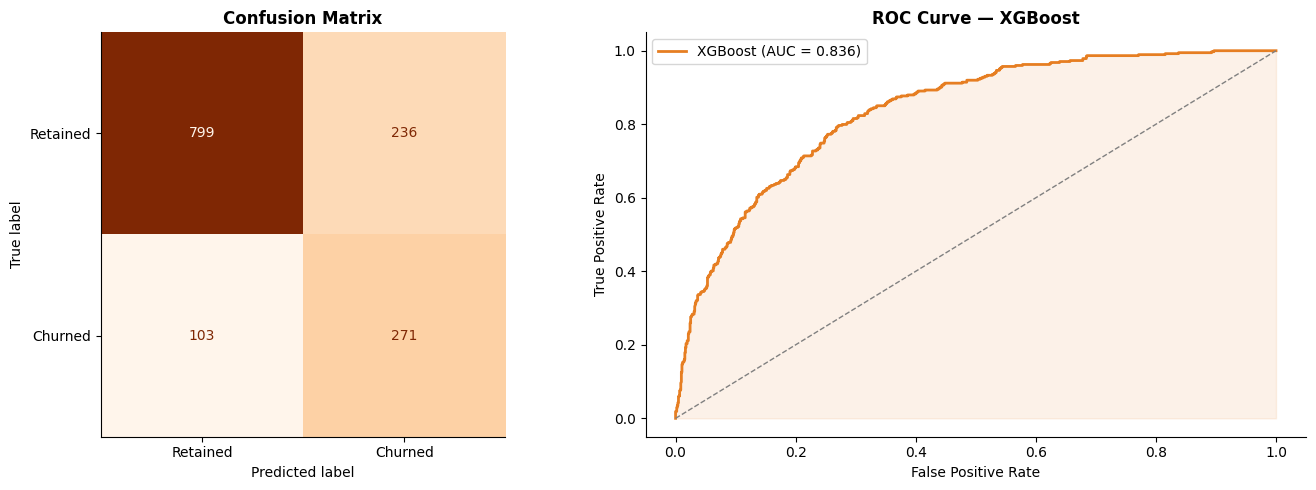

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Retained','Churned']
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e67e22')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — XGBoost', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

5. **Feature Importance**

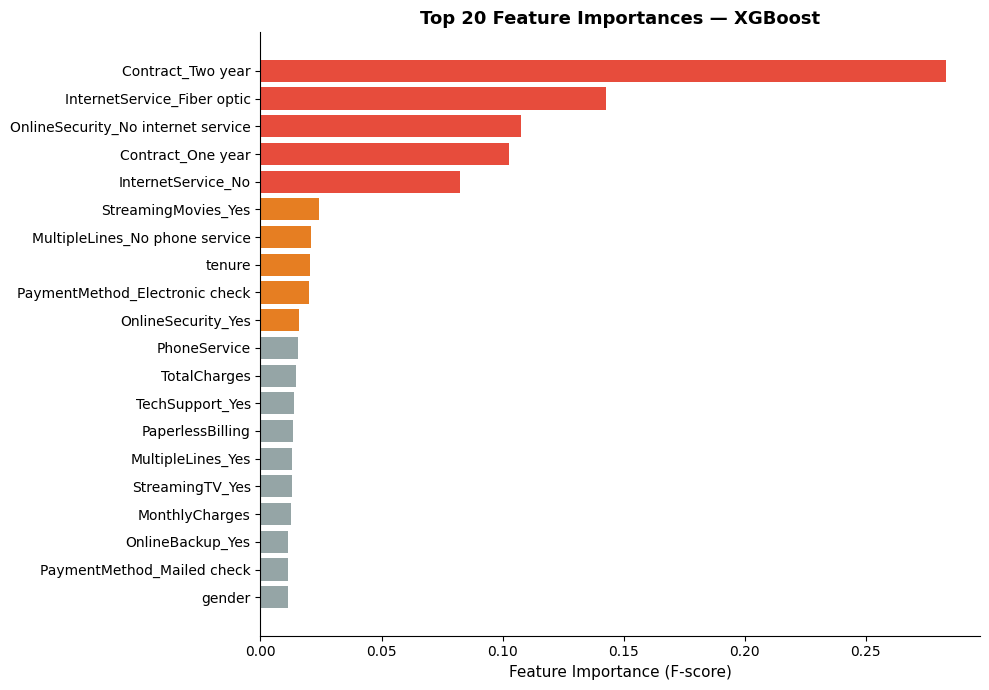


Top 10 features:
                           feature  importance
                 Contract_Two year    0.283004
       InternetService_Fiber optic    0.142896
OnlineSecurity_No internet service    0.107440
                 Contract_One year    0.102633
                InternetService_No    0.082603
               StreamingMovies_Yes    0.023999
    MultipleLines_No phone service    0.020679
                            tenure    0.020422
    PaymentMethod_Electronic check    0.019881
                OnlineSecurity_Yes    0.015929


In [13]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
top20 = importance_df.head(20)
colors = ['#e74c3c' if i < 5 else '#e67e22' if i < 10 else '#95a5a6'
          for i in range(len(top20))]
plt.barh(top20['feature'], top20['importance'], color=colors)
plt.xlabel('Feature Importance (F-score)', fontsize=11)
plt.title('Top 20 Feature Importances — XGBoost', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importance_df.head(10).to_string(index=False))

6. **Score All Customers & Save Predictions**

In [16]:
df_orig = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_orig['churn_probability_xgb'] = xgb_model.predict_proba(X)[:, 1]
df_orig['risk_segment'] = pd.cut(
    df_orig['churn_probability_xgb'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

at_risk = df_orig.sort_values('churn_probability_xgb', ascending=False)

print('Top 15 at-risk customers:')
print(at_risk[['customerID','tenure','MonthlyCharges','Contract',
               'churn_probability_xgb','risk_segment']].head(15).to_string(index=False))

print('\nRisk segment breakdown:')
print(df_orig['risk_segment'].value_counts())

at_risk[['customerID','churn_probability_xgb','risk_segment']].to_csv(
    'xgb_churn_predictions.csv', index=False)
print('\nSaved: xgb_churn_predictions.csv')

Top 15 at-risk customers:
customerID  tenure  MonthlyCharges       Contract  churn_probability_xgb risk_segment
2012-NWRPA      11           99.55 Month-to-month               0.987450         High
9300-AGZNL       1           94.00 Month-to-month               0.986130         High
8168-UQWWF      11           97.85 Month-to-month               0.985409         High
7216-EWTRS       1          100.80 Month-to-month               0.984856         High
9497-QCMMS       1           93.55 Month-to-month               0.983892         High
9248-OJYKK       1           76.45 Month-to-month               0.983145         High
0897-FEGMU      11           99.50 Month-to-month               0.983114         High
6861-XWTWQ       7           99.25 Month-to-month               0.983007         High
2609-IAICY       1           77.15 Month-to-month               0.981985         High
4910-GMJOT       1           94.60 Month-to-month               0.981970         High
8149-RSOUN       1          